# Bias Phase 2 — Data Analysis & Inter-Annotator Agreement

In [ ]:
import numpy as np
import pandas as pd
import krippendorff
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from scipy.stats import spearmanr, kendalltau
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns

df_conflicts = pd.read_csv('data/annotated_conflicts.csv')
df_merged = pd.read_csv('data/annotated_merged.csv')

# Ordinal scale: Far Left < Left < Center < Right < Far Right
label_order = ['Far Left', 'Left', 'Center', 'Right', 'Far Right']
label_to_int = {l: i for i, l in enumerate(label_order)}

annotators = ['bias_label_praveen', 'bias_label_ashini', 'bias_label_dinithi']

print(f"Conflicts: {len(df_conflicts)} rows")
print(f"Merged (single-annotator): {len(df_merged)} rows")

Conflicts: 150 rows
Merged (single-annotator): 1506 rows


## 1. Inter-Annotator Agreement (Ordinal)

Since bias labels follow an ordinal scale (Far Left → Left → Center → Right → Far Right), we use metrics that account for the **distance** between labels — a disagreement of Far Left vs Left is less severe than Far Left vs Far Right.

### 1.1 Pairwise Weighted Cohen's Kappa (Quadratic Weights)

In [37]:
print("=== Pairwise Weighted Cohen's Kappa (quadratic weights) ===\n")
for a1, a2 in combinations(annotators, 2):
    mask = df_conflicts[a1].notna() & df_conflicts[a2].notna()
    subset = df_conflicts[mask]
    name1, name2 = a1.split('_')[-1], a2.split('_')[-1]
    
    # Exact agreement
    exact_agree = (subset[a1] == subset[a2]).mean() * 100
    
    # Weighted kappa (quadratic) — treats ordinal distance
    kappa_w = cohen_kappa_score(
        subset[a1].map(label_to_int), subset[a2].map(label_to_int),
        weights='quadratic', labels=list(range(5))
    )
    
    # Adjacent agreement (exact OR off-by-one)
    diff = (subset[a1].map(label_to_int) - subset[a2].map(label_to_int)).abs()
    adjacent_agree = (diff <= 1).mean() * 100
    
    print(f"{name1} vs {name2} (n={len(subset)}):")
    print(f"  Weighted Kappa (quadratic): {kappa_w:.4f}")
    print(f"  Exact agreement:            {exact_agree:.1f}%")
    print(f"  Adjacent agreement (±1):    {adjacent_agree:.1f}%")
    print()

=== Pairwise Weighted Cohen's Kappa (quadratic weights) ===

praveen vs ashini (n=150):
  Weighted Kappa (quadratic): 0.7959
  Exact agreement:            73.3%
  Adjacent agreement (±1):    96.7%

praveen vs dinithi (n=150):
  Weighted Kappa (quadratic): 0.7438
  Exact agreement:            68.0%
  Adjacent agreement (±1):    97.3%

ashini vs dinithi (n=150):
  Weighted Kappa (quadratic): 0.7546
  Exact agreement:            66.7%
  Adjacent agreement (±1):    98.0%



### 1.2 Krippendorff's Alpha (Ordinal)

Handles missing raters and uses ordinal distance function — the standard multi-rater ordinal IAA metric.

In [38]:
# Build reliability data matrix for krippendorff (raters × items, NaN for missing)
reliability_data = []
for col in annotators:
    reliability_data.append(
        df_conflicts[col].map(label_to_int).values.astype(float)
    )
reliability_data = np.array(reliability_data)

alpha_ordinal = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='ordinal')
alpha_nominal = krippendorff.alpha(reliability_data=reliability_data, level_of_measurement='nominal')

print(f"=== Krippendorff's Alpha (all 3 annotators, n={len(df_conflicts)}) ===\n")
print(f"  Ordinal alpha:  {alpha_ordinal:.4f}")
print(f"  Nominal alpha:  {alpha_nominal:.4f}  (for comparison — ignores scale distance)")
print()

# Also compute on the subset where all 3 annotated
mask_all = df_conflicts[annotators].notna().all(axis=1)
rel_all3 = []
for col in annotators:
    rel_all3.append(df_conflicts.loc[mask_all, col].map(label_to_int).values.astype(float))
rel_all3 = np.array(rel_all3)

alpha_all3 = krippendorff.alpha(reliability_data=rel_all3, level_of_measurement='ordinal')
print(f"Ordinal alpha (only articles with all 3 raters, n={mask_all.sum()}): {alpha_all3:.4f}")

=== Krippendorff's Alpha (all 3 annotators, n=150) ===

  Ordinal alpha:  0.7609
  Nominal alpha:  0.5395  (for comparison — ignores scale distance)

Ordinal alpha (only articles with all 3 raters, n=150): 0.7609


### 1.3 Spearman & Kendall Rank Correlations (Pairwise)

In [39]:
print("=== Pairwise Rank Correlations ===\n")
for a1, a2 in combinations(annotators, 2):
    mask = df_conflicts[a1].notna() & df_conflicts[a2].notna()
    subset = df_conflicts[mask]
    name1, name2 = a1.split('_')[-1], a2.split('_')[-1]
    
    v1 = subset[a1].map(label_to_int)
    v2 = subset[a2].map(label_to_int)
    
    rho, p_rho = spearmanr(v1, v2)
    tau, p_tau = kendalltau(v1, v2)
    
    print(f"{name1} vs {name2} (n={len(subset)}):")
    print(f"  Spearman rho: {rho:.4f}  (p={p_rho:.4e})")
    print(f"  Kendall tau:  {tau:.4f}  (p={p_tau:.4e})")
    print()

=== Pairwise Rank Correlations ===

praveen vs ashini (n=150):
  Spearman rho: 0.8008  (p=9.0558e-35)
  Kendall tau:  0.7527  (p=6.9817e-27)

praveen vs dinithi (n=150):
  Spearman rho: 0.7374  (p=5.3477e-27)
  Kendall tau:  0.6905  (p=6.0067e-23)

ashini vs dinithi (n=150):
  Spearman rho: 0.7508  (p=1.8944e-28)
  Kendall tau:  0.6983  (p=5.0710e-23)



### 1.4 Pairwise Confusion Matrices (Ordinal Heatmaps)

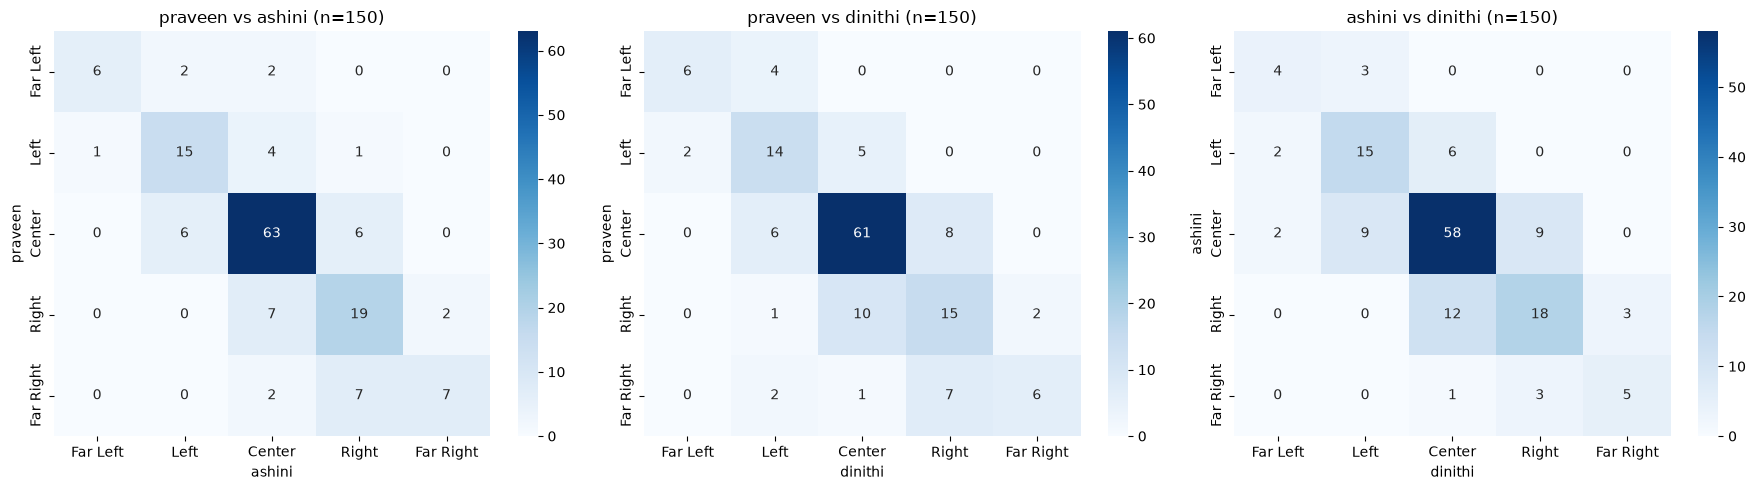

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (a1, a2) in enumerate(combinations(annotators, 2)):
    mask = df_conflicts[a1].notna() & df_conflicts[a2].notna()
    subset = df_conflicts[mask]
    name1, name2 = a1.split('_')[-1], a2.split('_')[-1]
    
    cm = confusion_matrix(
        subset[a1].map(label_to_int), subset[a2].map(label_to_int),
        labels=list(range(5))
    )
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_order, yticklabels=label_order,
                ax=axes[idx])
    axes[idx].set_title(f'{name1} vs {name2} (n={len(subset)})')
    axes[idx].set_xlabel(name2)
    axes[idx].set_ylabel(name1)

plt.tight_layout()
plt.show()

### 1.5 Disagreement Distance Distribution

How far apart are annotators when they disagree? (0 = exact match, 1 = adjacent, 4 = maximum)

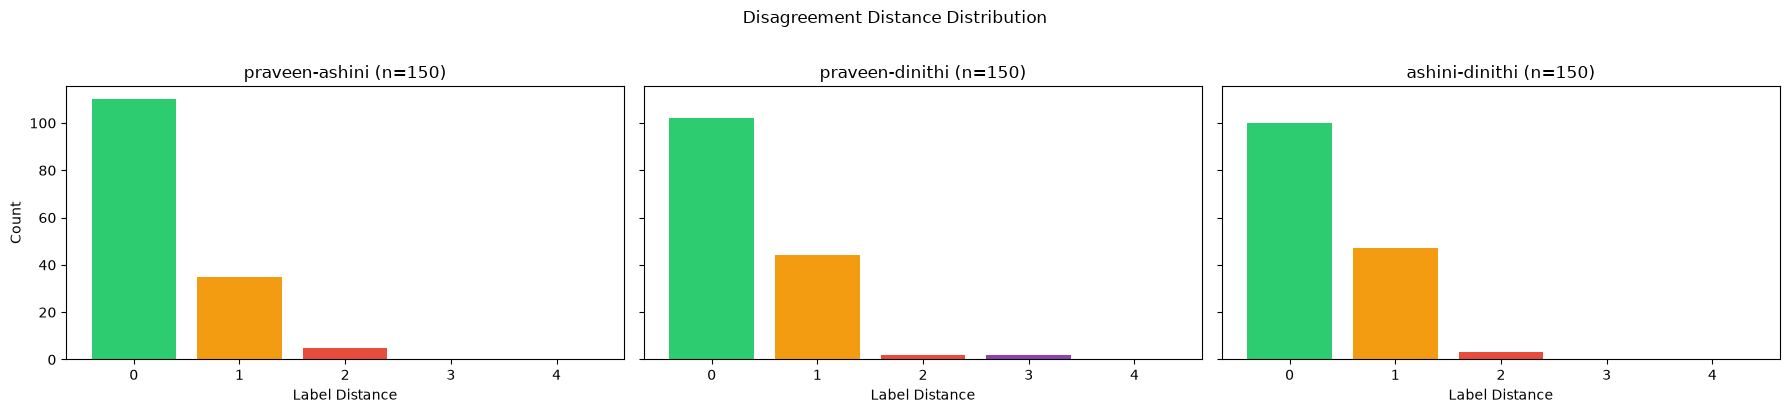

=== Distance Summary ===

praveen-ashini: mean distance = 0.30, exact = 110, adjacent = 35, far (≥2) = 5
praveen-dinithi: mean distance = 0.36, exact = 102, adjacent = 44, far (≥2) = 4
ashini-dinithi: mean distance = 0.35, exact = 100, adjacent = 47, far (≥2) = 3


In [41]:
all_diffs = []
pair_names = []

for a1, a2 in combinations(annotators, 2):
    mask = df_conflicts[a1].notna() & df_conflicts[a2].notna()
    subset = df_conflicts[mask]
    name1, name2 = a1.split('_')[-1], a2.split('_')[-1]
    
    diff = (subset[a1].map(label_to_int) - subset[a2].map(label_to_int)).abs()
    all_diffs.append(diff)
    pair_names.append(f"{name1}-{name2}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for i, (diffs, name) in enumerate(zip(all_diffs, pair_names)):
    dist = diffs.value_counts().reindex(range(5), fill_value=0)
    axes[i].bar(dist.index, dist.values, color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad', '#2c3e50'])
    axes[i].set_title(f'{name} (n={len(diffs)})')
    axes[i].set_xlabel('Label Distance')
    axes[i].set_xticks(range(5))

axes[0].set_ylabel('Count')
plt.suptitle('Disagreement Distance Distribution', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print("=== Distance Summary ===\n")
for diffs, name in zip(all_diffs, pair_names):
    print(f"{name}: mean distance = {diffs.mean():.2f}, "
          f"exact = {(diffs == 0).sum()}, "
          f"adjacent = {(diffs == 1).sum()}, "
          f"far (≥2) = {(diffs >= 2).sum()}")

### 1.6 Label Distribution per Annotator (in conflicts)

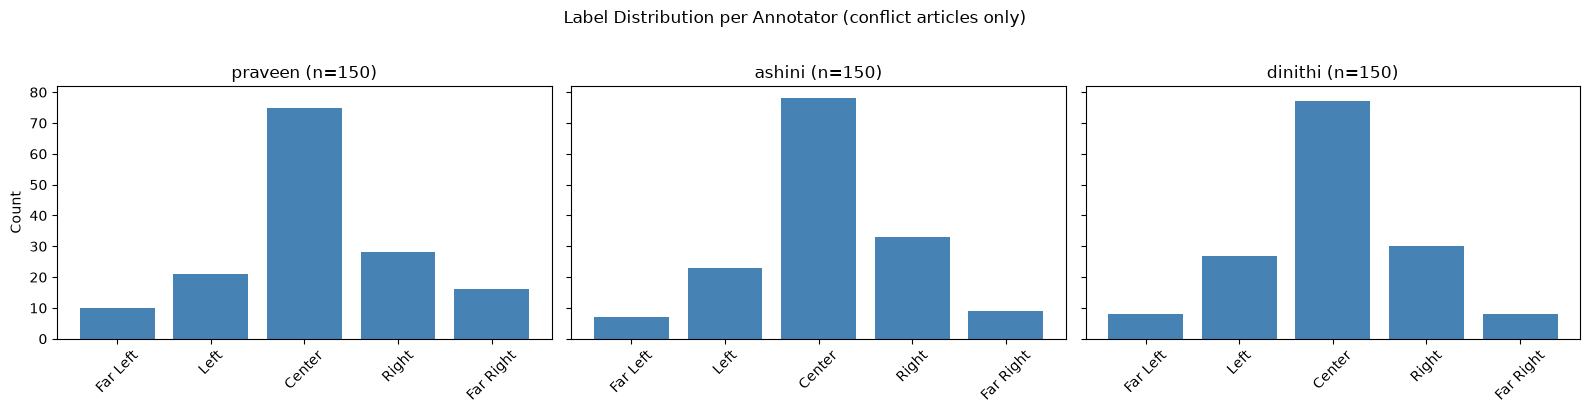

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for i, col in enumerate(annotators):
    name = col.split('_')[-1]
    counts = df_conflicts[col].dropna().map(lambda x: label_order.index(x) if x in label_order else -1)
    counts = df_conflicts[col].dropna().value_counts().reindex(label_order, fill_value=0)
    axes[i].bar(label_order, counts.values, color='steelblue')
    axes[i].set_title(f'{name} (n={df_conflicts[col].notna().sum()})')
    axes[i].tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Count')
plt.suptitle('Label Distribution per Annotator (conflict articles only)', y=1.02)
plt.tight_layout()
plt.show()

## 2. Merged Dataset Description

In [43]:
df_merged.info()
print()
print("=== Bias Label Distribution ===")
print(df_merged['bias_label'].value_counts(dropna=False))
print()
print("=== Annotator Distribution ===")
print(df_merged['annotator'].value_counts())
print()
print("=== Publisher Distribution ===")
print(df_merged['publisher'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 1506 entries, 0 to 1505
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   article_id    1506 non-null   str  
 1   publisher     1506 non-null   str  
 2   url           1506 non-null   str  
 3   published_at  1506 non-null   str  
 4   title         1506 non-null   str  
 5   body_text     1505 non-null   str  
 6   bias_label    1506 non-null   str  
 7   annotator     1506 non-null   str  
dtypes: str(8)
memory usage: 94.3 KB

=== Bias Label Distribution ===
bias_label
Center       661
Left         348
Right        307
Far Left     115
Far Right     75
Name: count, dtype: int64

=== Annotator Distribution ===
annotator
dinithi    600
ashini     598
praveen    308
Name: count, dtype: int64

=== Publisher Distribution ===
publisher
BBC Sinhala           381
Lanka Deepa           377
Ada                   376
Ada Derana Sinhala    372
Name: count, dtype: int64


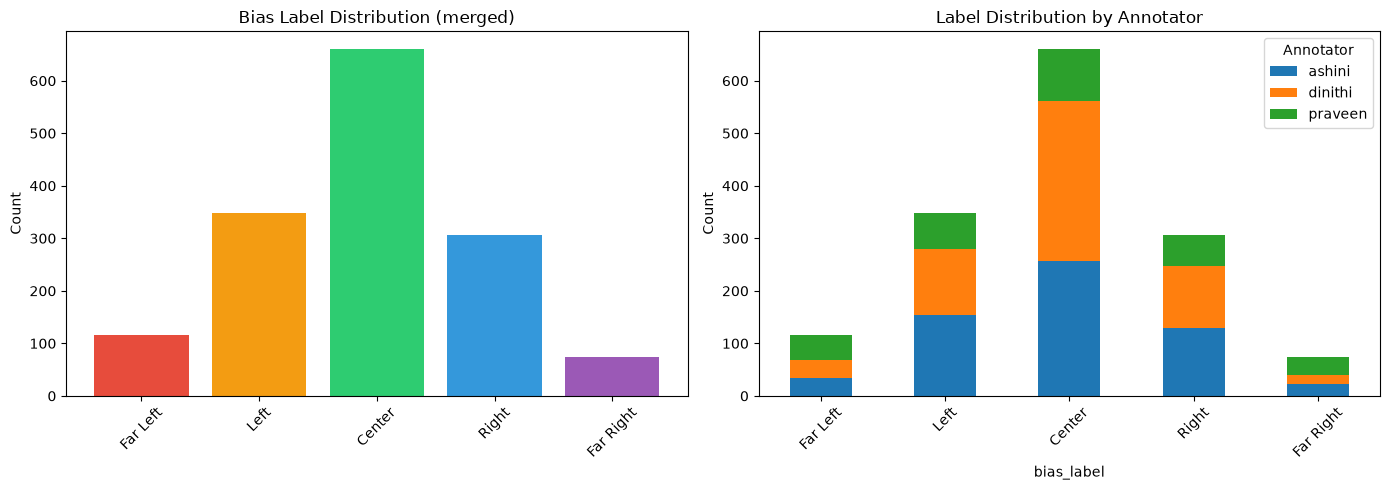

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution
label_counts = df_merged['bias_label'].value_counts().reindex(label_order)
axes[0].bar(label_order, label_counts.values, color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db', '#9b59b6'])
axes[0].set_title('Bias Label Distribution (merged)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Per-annotator label distribution (stacked)
ct = pd.crosstab(df_merged['bias_label'], df_merged['annotator']).reindex(label_order)
ct.plot(kind='bar', ax=axes[1], stacked=True)
axes[1].set_title('Label Distribution by Annotator')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Annotator')

plt.tight_layout()
plt.show()

### Conflicting samples - Finding the correct label



In [ ]:
# Ordinal mapping
ordinal_map = {"Far Left": 1, "Left": 2, "Center": 3, "Right": 4, "Far Right": 5}
reverse_map = {v: k for k, v in ordinal_map.items()}

label_cols = ["bias_label_praveen", "bias_label_ashini", "bias_label_dinithi"]

# Convert to numeric, take median, round to nearest ordinal, map back
numeric = df_conflicts[label_cols].replace(ordinal_map)
df_conflicts["bias_label"] = numeric.median(axis=1).round().astype(int).map(reverse_map)

df_conflicts.head()

,article_id,publisher,url,published_at,title,body_text,bias_label_praveen,bias_label_ashini,bias_label_dinithi,annotator_count,assigned_label
0,026c62a7-2146-50af-842f-119783941fb3,BBC Sinhala,https://www.bbc.com/sinhala/articles/c2dp41z26xgo,2024-09-24 00:00:00+00:00,ආචාර්ය හරිනි අමරසූරිය: දශක 2කට පසු ශ්‍රී ලංකාව...,ආචාර්ය හරිනි අමරසූරිය: දශක 2කට පසු ශ්‍රී ලංකාව...,Far Left,Far Left,Far Left,3,Far Left
1,02e54e75-12b8-5d3e-b9d7-c25eae59a942,Ada Derana Sinhala,http://sinhala.adaderana.lk/news/196998,2024-05-25 00:00:00+00:00,මෙවර කුණාටු වඩාත් ප්‍රචණ්ඩකාරී වෙයි,මෙවර කුණාටු වඩාත් ප්‍රචණ්ඩකාරී වෙයි\n\nමෙවර අත...,Center,Center,Center,3,Center
2,06c03615-b9c1-5e12-a6b7-57cb4585038e,BBC Sinhala,https://www.bbc.com/sinhala/articles/c2kxlpv75k5o,2025-01-08 00:00:00+00:00,ඔබේ බැංකු තැන්පතුවලින් අය කෙරෙන රැඳවුම් බද්දට ...,ඔබේ බැංකු තැන්පතුවලින් අය කෙරෙන රැඳවුම් බද්දට ...,Right,Right,Center,3,Right
3,0afb934e-98fe-5f0e-adc8-3c296b2c20cc,Lanka Deepa,https://www.lankadeepa.lk/news/වපතට-පත-පරදශ-හය...,2025-11-28 00:00:00+00:00,විපතට පත් ප්‍රදේශ හොයන්න ගුවන් මෙහෙයුමක්,විපතට පත් ප්‍රදේශ හොයන්න ගුවන් මෙහෙයුමක්\n\nවි...,Center,Center,Left,3,Center
4,0df9a153-ce95-5378-beb3-a69ffdb0b17f,Ada,https://www.ada.lk/breaking_news/ශාන්-ගේ-ගෝලයෙ...,2024-03-21 00:00:00+00:00,ශාන් ගේ ගෝලයෙකු හෙරෝයින් සමග අත්අඩංගුවට,ශාන් ගේ ගෝලයෙකු හෙරෝයින් සමග අත්අඩංගුවට\n\nමතු...,Center,Center,Right,3,Center


### Merging conflicts and single annotator datasets

In [35]:
#Unicode normalization (NFC - canonical decomposition + composition)
import unicodedata                                                                                                                                          
                                                                                                                                                        
# Unicode normalization (NFC - canonical decomposition + composition)                                                                                       
df['body_text'] = df['body_text'].apply(lambda x: unicodedata.normalize('NFC', x))                                                                        
df['title'] = df['title'].apply(lambda x: unicodedata.normalize('NFC', x))

df.head()


,article_id,title,body_text,bias_label
0,005336e4-16fd-5a46-8eaf-aa3ef9ee9032,ලංකාවේ පළමු ස්වයංක්‍රීය දේශසීමා පාලන පද්ධතිය ව...,ලංකාවේ පළමු ස්වයංක්‍රීය දේශසීමා පාලන පද්ධතිය ව...,Left
1,00862f54-3e40-5360-abfd-8805b11bcdf7,රුසියාවට කළා වගේ ඊශ්‍රායලයටත් ක්‍රීඩා තහනමක් ?,රුසියාවට කළා වගේ ඊශ්‍රායලයටත් ක්‍රීඩා තහනමක් ?...,Center
2,01338392-d1a3-502f-bf49-9d1ee204ed22,අයිස් මත්ද්‍රව්‍ය කිලෝ 400ක් සමග කොටු වූ සැකකර...,අයිස් මත්ද්‍රව්‍ය කිලෝ 400ක් සමග කොටු වූ සැකකර...,Center
3,01529750-6900-5309-a945-48e448125e25,කන්ජිපානිට සහ ගනේමුල්ලේ සංජීවට රටින් පැනයෑමට උ...,කන්ජිපානිට සහ ගනේමුල්ලේ සංජීවට රටින් පැනයෑමට උ...,Right
4,0188cae7-ed52-5e3b-8e53-69229d37df7f,පාස්කු ඉරුදින ත්‍රස්ත ප්‍රහාරය එල්ල වී අදට පස්...,පාස්කු ඉරුදින ත්‍රස්ත ප්‍රහාරය එල්ල වී අදට පස්...,Center
